# 🤖 AI-Generated Image Detector — GAN Discriminator Approach

> **Core Idea:** A GAN has two networks — a **Generator** (forges fake images) and a **Discriminator** (catches fakes). Unlike a standard CNN classifier that learns from labels alone, the Discriminator here is forced to sharpen its detection skills *adversarially* — the Generator keeps trying to fool it, making it progressively better at spotting AI-generated images.
>
> After training, we extract the **Discriminator** and use it as our final detector.

---

| Component | Role |
|---|---|
| **Generator** | Synthesizes fake-looking images from random noise — acts as an adversary during training |
| **Discriminator** | Learns to separate Real vs Fake — becomes our **AI Detector** |

**Framework:** PyTorch (vs TensorFlow in the CNN approach)  
**Architecture:** PatchGAN-style Discriminator + DCGAN Generator  
**Dataset:** Same folder structure — `real/` and `fake/` splits

## 1. Imports & Setup

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import seaborn as sns

# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Using device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"   GPU           : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM          : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

print(f"   PyTorch       : {torch.__version__}")

🖥️  Using device : cuda
   GPU           : Tesla T4
   VRAM          : 15.6 GB
   PyTorch       : 2.10.0+cu128


## 2. Configuration

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Central config — change paths here if your dataset is mounted elsewhere
# ─────────────────────────────────────────────────────────────────────────────
class Config:
    # Dataset paths (Kaggle-style)
    TRAIN_DIR  = "/kaggle/input/datasets/ankitkandulna/ai-vs-real-my-dataset/Dataset/Training/"
    TEST_DIR   = "/kaggle/input/datasets/ankitkandulna/ai-vs-real-my-dataset/Dataset/Testing/"

    # Image settings
    IMG_SIZE   = 64          # GAN works best at 64×64; bump to 128 if VRAM allows
    CHANNELS   = 3

    # GAN settings
    LATENT_DIM = 100         # Noise vector size fed into Generator
    FEATURES_G = 64          # Base feature maps in Generator
    FEATURES_D = 64          # Base feature maps in Discriminator

    # Training
    EPOCHS     = 30
    BATCH_SIZE = 64
    LR_G       = 0.0002      # Generator learning rate
    LR_D       = 0.0002      # Discriminator learning rate
    BETA1      = 0.5         # Adam β₁ (standard GAN value)
    BETA2      = 0.999

    # Label smoothing (stabilises GAN training)
    REAL_LABEL = 0.9
    FAKE_LABEL = 0.1

    # Checkpoint
    DISC_PATH  = "best_discriminator.pth"

CFG = Config()
print("✅ Config loaded")
print(f"   Image size  : {CFG.IMG_SIZE}×{CFG.IMG_SIZE}")
print(f"   Latent dim  : {CFG.LATENT_DIM}")
print(f"   Epochs      : {CFG.EPOCHS}")
print(f"   Batch size  : {CFG.BATCH_SIZE}")

✅ Config loaded
   Image size  : 64×64
   Latent dim  : 100
   Epochs      : 30
   Batch size  : 64


## 3. Dataset & DataLoader

In [3]:
class RealFakeDataset(Dataset):
    """
    Scans `root_dir` for sub-folders named 'real' and 'fake'.
    Label: 1 = Real, 0 = Fake  (same convention as CNN notebook)
    """
    EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp'}

    def __init__(self, root_dir: str, transform=None):
        self.transform = transform
        self.samples   = []   # (path, label)

        root = Path(root_dir)
        for folder in root.iterdir():
            if not folder.is_dir():
                continue
            # Check ONLY the immediate folder name (avoids substring-match bugs)
            folder_name = folder.name.lower()
            if folder_name == 'real':
                label = 1
            elif folder_name == 'fake':
                label = 0
            else:
                print(f"⚠️  Skipping unknown folder: {folder.name}")
                continue

            for img_path in folder.iterdir():
                if img_path.suffix.lower() in self.EXTENSIONS:
                    self.samples.append((str(img_path), label))

        print(f"📂 {root_dir}")
        real_count = sum(1 for _, l in self.samples if l == 1)
        fake_count = sum(1 for _, l in self.samples if l == 0)
        print(f"   ✅ Real : {real_count:,}")
        print(f"   🤖 Fake : {fake_count:,}")
        print(f"   Total  : {len(self.samples):,}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)


# ── Transforms ───────────────────────────────────────────────────────────────
# GAN discriminator expects images normalised to [-1, 1]
train_transform = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),   # → [-1, 1]
])

test_transform = transforms.Compose([
    transforms.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# ── Build datasets ───────────────────────────────────────────────────────────
print("=" * 50)
print("Training set")
print("=" * 50)
train_ds = RealFakeDataset(CFG.TRAIN_DIR, transform=train_transform)

print("=" * 50)
print("Test set")
print("=" * 50)
test_ds  = RealFakeDataset(CFG.TEST_DIR, transform=test_transform)

# ── DataLoaders ──────────────────────────────────────────────────────────────
train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"\n🔄 Train batches : {len(train_loader)}")
print(f"🔄 Test batches  : {len(test_loader)}")

Training set
📂 /kaggle/input/datasets/ankitkandulna/ai-vs-real-my-dataset/Dataset/Training/
   ✅ Real : 12,202
   🤖 Fake : 12,202
   Total  : 24,404
Test set
📂 /kaggle/input/datasets/ankitkandulna/ai-vs-real-my-dataset/Dataset/Testing/
   ✅ Real : 4,600
   🤖 Fake : 4,600
   Total  : 9,200

🔄 Train batches : 382
🔄 Test batches  : 144


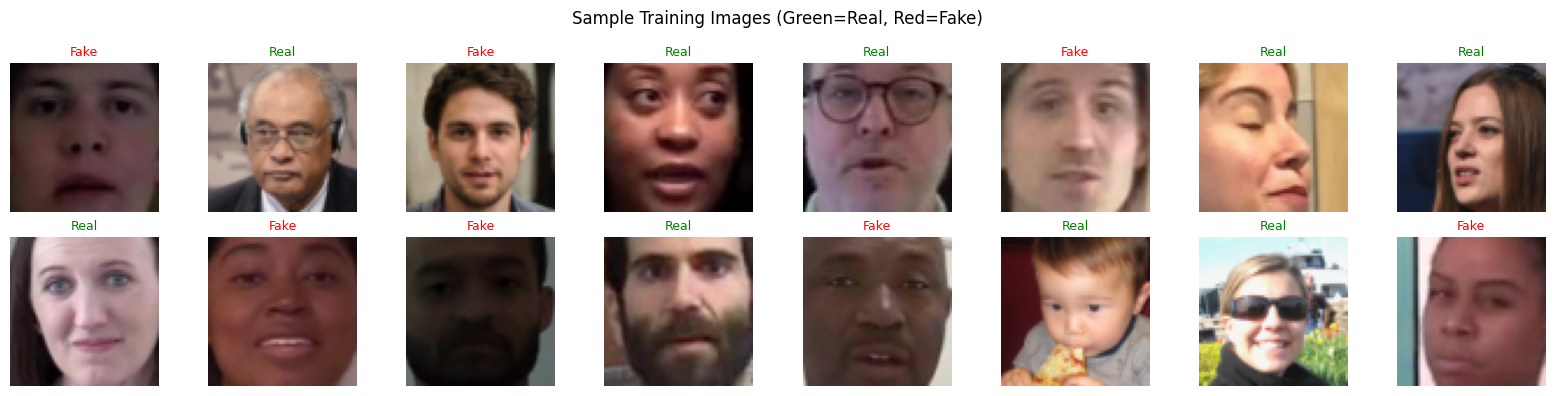

In [4]:
# ── Visualise a sample batch ─────────────────────────────────────────────────
def denorm(tensor):
    """Undo the [-1,1] normalisation for display."""
    return (tensor * 0.5 + 0.5).clamp(0, 1)

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(16, 4))

for i, ax in enumerate(axes.flat):
    if i >= len(imgs): break
    img_np = denorm(imgs[i]).permute(1, 2, 0).numpy()
    ax.imshow(img_np)
    ax.set_title("Real" if labels[i].item() == 1 else "Fake",
                 color='green' if labels[i].item() == 1 else 'red', fontsize=9)
    ax.axis('off')

plt.suptitle("Sample Training Images (Green=Real, Red=Fake)", fontsize=12)
plt.tight_layout()
plt.show()

## 4. GAN Architecture

### Why PatchGAN for Detection?

A standard GAN discriminator outputs a **single scalar** (real/fake for the whole image). A **PatchGAN** discriminator instead outputs an **N×N grid** — each patch independently voted on. This forces the model to focus on *local* texture and frequency artefacts, which are exactly the kind of traces AI-generated images leave behind (checkerboard patterns, unnatural skin texture, spectral fingerprints).

```
Input Image (3×64×64)
       │
  ┌────▼────┐      Conv Blocks with Spectral Norm
  │  D(x)  │  ──► 4×4 patch grid of scores  ──► mean → sigmoid
  └─────────┘
```

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# Helper: conv block for Discriminator (Conv → SpectralNorm → LeakyReLU)
# Spectral Normalisation keeps the Discriminator Lipschitz-stable
# ─────────────────────────────────────────────────────────────────────────────
def disc_block(in_ch, out_ch, stride=2, bn=True):
    layers = [
        nn.utils.spectral_norm(
            nn.Conv2d(in_ch, out_ch, kernel_size=4, stride=stride, padding=1, bias=False)
        ),
    ]
    if bn:
        layers.append(nn.BatchNorm2d(out_ch))
    layers.append(nn.LeakyReLU(0.2, inplace=True))
    return nn.Sequential(*layers)


class Discriminator(nn.Module):
    """
    PatchGAN-style Discriminator.
    Outputs a spatial grid of real/fake scores (not a single number).
    We average the grid to get the final probability.
    """
    def __init__(self, img_channels=3, features=64):
        super().__init__()
        # Input: (B, 3, 64, 64)
        self.net = nn.Sequential(
            disc_block(img_channels,   features,    bn=False),  # → (B, 64,  32, 32)
            disc_block(features,       features*2),             # → (B, 128, 16, 16)
            disc_block(features*2,     features*4),             # → (B, 256,  8,  8)
            disc_block(features*4,     features*8),             # → (B, 512,  4,  4)
            nn.utils.spectral_norm(
                nn.Conv2d(features*8, 1, kernel_size=4, stride=1, padding=0)
            ),                                                  # → (B,   1,  1,  1)
            nn.Sigmoid()
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.normal_(m.weight.data, 0.0, 0.02)

    def forward(self, x):
        out = self.net(x)               # (B, 1, 1, 1)
        return out.view(-1)             # (B,)  — one score per image


# ─────────────────────────────────────────────────────────────────────────────
# Generator (DCGAN-style)
# Not used for detection — only here to adversarially train the Discriminator
# ─────────────────────────────────────────────────────────────────────────────
def gen_block(in_ch, out_ch):
    return nn.Sequential(
        nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True)
    )


class Generator(nn.Module):
    """
    Takes a noise vector z ∈ R^latent_dim and synthesises a fake image.
    Output: (B, 3, 64, 64) with pixel values in [-1, 1].
    """
    def __init__(self, latent_dim=100, img_channels=3, features=64):
        super().__init__()
        self.net = nn.Sequential(
            # Project & reshape: (B, 100) → (B, 512, 4, 4)
            nn.ConvTranspose2d(latent_dim, features*8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(features*8),
            nn.ReLU(inplace=True),
            gen_block(features*8, features*4),   # → (B, 256,  8,  8)
            gen_block(features*4, features*2),   # → (B, 128, 16, 16)
            gen_block(features*2, features),     # → (B,  64, 32, 32)
            nn.ConvTranspose2d(features, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh()                            # → (B,   3, 64, 64) in [-1, 1]
        )
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.ConvTranspose2d, nn.Conv2d)):
                nn.init.normal_(m.weight.data, 0.0, 0.02)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.normal_(m.weight.data, 1.0, 0.02)
                nn.init.constant_(m.bias.data, 0)

    def forward(self, z):
        return self.net(z.view(z.size(0), z.size(1), 1, 1))


# ── Instantiate ──────────────────────────────────────────────────────────────
D = Discriminator(img_channels=CFG.CHANNELS, features=CFG.FEATURES_D).to(DEVICE)
G = Generator(latent_dim=CFG.LATENT_DIM, img_channels=CFG.CHANNELS, features=CFG.FEATURES_G).to(DEVICE)

print("\n" + "="*60)
print("DISCRIMINATOR  (our final AI Detector)")
print("="*60)
print(D)

param_D = sum(p.numel() for p in D.parameters() if p.requires_grad)
param_G = sum(p.numel() for p in G.parameters() if p.requires_grad)
print(f"\n🔢 Discriminator parameters : {param_D:,}")
print(f"🔢 Generator parameters     : {param_G:,}")


DISCRIMINATOR  (our final AI Detector)
Discriminator(
  (net): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (1): Sequential(
      (0): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (2): Sequential(
      (0): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (3): Sequential(
      (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(

## 5. GAN Training

### Training Loop Logic

Each batch alternates between two updates:

**Step 1 — Train Discriminator:**
- Feed *real* images → Discriminator should output ≈ 1
- Generate *fake* images via Generator → Discriminator should output ≈ 0
- Backprop on combined loss, update only `D` weights

**Step 2 — Train Generator:**
- Generate fake images → feed to Discriminator
- Loss = how much Discriminator was *fooled* (we want D to output ≈ 1 for fakes)
- Backprop, update only `G` weights

The two networks play a minimax game: G tries to fool D, D tries not to be fooled. At the end, D has learned rich real-vs-fake representations purely through adversarial pressure.

> **Label smoothing** is used (0.9 for real, 0.1 for fake) to prevent the Discriminator from becoming overconfident and collapsing.

In [6]:
# ── Optimisers ───────────────────────────────────────────────────────────────
opt_D = optim.Adam(D.parameters(), lr=CFG.LR_D, betas=(CFG.BETA1, CFG.BETA2))
opt_G = optim.Adam(G.parameters(), lr=CFG.LR_G, betas=(CFG.BETA1, CFG.BETA2))

# Cosine annealing to smooth out late-stage oscillations
sched_D = optim.lr_scheduler.CosineAnnealingLR(opt_D, T_max=CFG.EPOCHS)
sched_G = optim.lr_scheduler.CosineAnnealingLR(opt_G, T_max=CFG.EPOCHS)

criterion = nn.BCELoss()

# Fixed noise — used to watch Generator progress across epochs
fixed_noise = torch.randn(16, CFG.LATENT_DIM, device=DEVICE)


# ─────────────────────────────────────────────────────────────────────────────
# Training Loop
# ─────────────────────────────────────────────────────────────────────────────
history = {'D_loss': [], 'G_loss': [], 'D_real': [], 'D_fake': [], 'epoch_time': []}
best_d_loss = float('inf')

print("🚀 Starting GAN training...\n")

for epoch in range(1, CFG.EPOCHS + 1):
    t0 = time.time()
    epoch_D_loss, epoch_G_loss = 0.0, 0.0
    epoch_D_real, epoch_D_fake = 0.0, 0.0
    num_batches = 0

    D.train(); G.train()

    for real_imgs, _ in tqdm(train_loader, desc=f"Epoch {epoch}/{CFG.EPOCHS}", leave=False):
        B = real_imgs.size(0)
        real_imgs = real_imgs.to(DEVICE)

        # ── Labels (with smoothing) ───────────────────────────────────────────
        real_labels = torch.full((B,), CFG.REAL_LABEL, device=DEVICE)
        fake_labels = torch.full((B,), CFG.FAKE_LABEL, device=DEVICE)

        # ═══════════════════════════════════════════════════════════════════════
        # STEP 1 — Update Discriminator
        # ═══════════════════════════════════════════════════════════════════════
        opt_D.zero_grad()

        # Real images through D
        d_real = D(real_imgs)
        loss_D_real = criterion(d_real, real_labels)

        # Fake images through D (detach G's graph — we're not training G here)
        noise = torch.randn(B, CFG.LATENT_DIM, device=DEVICE)
        fake_imgs = G(noise).detach()
        d_fake = D(fake_imgs)
        loss_D_fake = criterion(d_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()

        # ═══════════════════════════════════════════════════════════════════════
        # STEP 2 — Update Generator
        # ═══════════════════════════════════════════════════════════════════════
        opt_G.zero_grad()

        noise = torch.randn(B, CFG.LATENT_DIM, device=DEVICE)
        fake_imgs = G(noise)
        # Generator wants D to classify its fakes as REAL
        d_fake_for_G = D(fake_imgs)
        loss_G = criterion(d_fake_for_G, real_labels)  # target = real_labels!
        loss_G.backward()
        opt_G.step()

        # ── Accumulate stats ──────────────────────────────────────────────────
        epoch_D_loss += loss_D.item()
        epoch_G_loss += loss_G.item()
        epoch_D_real += d_real.mean().item()
        epoch_D_fake += d_fake.mean().item()
        num_batches  += 1

    sched_D.step(); sched_G.step()

    avg_D = epoch_D_loss / num_batches
    avg_G = epoch_G_loss / num_batches
    avg_real = epoch_D_real / num_batches
    avg_fake = epoch_D_fake / num_batches
    elapsed = time.time() - t0

    history['D_loss'].append(avg_D)
    history['G_loss'].append(avg_G)
    history['D_real'].append(avg_real)
    history['D_fake'].append(avg_fake)
    history['epoch_time'].append(elapsed)

    print(f"Epoch [{epoch:>3}/{CFG.EPOCHS}]  "
          f"D_loss: {avg_D:.4f}  G_loss: {avg_G:.4f}  "
          f"D(real): {avg_real:.3f}  D(fake): {avg_fake:.3f}  "
          f"⏱ {elapsed:.1f}s")

    # ── Save best discriminator ───────────────────────────────────────────────
    if avg_D < best_d_loss:
        best_d_loss = avg_D
        torch.save(D.state_dict(), CFG.DISC_PATH)
        print(f"   ✅ Saved best discriminator (D_loss={best_d_loss:.4f})")

print("\n🎉 Training complete!")
print(f"   Best D_loss : {best_d_loss:.4f}")
print(f"   Avg time/epoch : {np.mean(history['epoch_time']):.1f}s")

🚀 Starting GAN training...



Epoch 1/30:   0%|          | 0/382 [00:00<?, ?it/s]

Epoch [  1/30]  D_loss: 0.9280  G_loss: 3.2727  D(real): 0.783  D(fake): 0.219  ⏱ 85.6s
   ✅ Saved best discriminator (D_loss=0.9280)


Epoch 2/30:   0%|          | 0/382 [00:00<?, ?it/s]

Epoch [  2/30]  D_loss: 0.9516  G_loss: 2.3463  D(real): 0.741  D(fake): 0.258  ⏱ 38.7s


...

Epoch [ 28/30]  D_loss: 0.7303  G_loss: 1.6181  D(real): 0.817  D(fake): 0.183  ⏱ 38.8s
   ✅ Saved best discriminator (D_loss=0.7303)


Epoch 29/30:   0%|          | 0/382 [00:00<?, ?it/s]

Epoch [ 29/30]  D_loss: 0.7286  G_loss: 1.6258  D(real): 0.817  D(fake): 0.182  ⏱ 38.6s
   ✅ Saved best discriminator (D_loss=0.7286)


Epoch 30/30:   0%|          | 0/382 [00:00<?, ?it/s]

Epoch [ 30/30]  D_loss: 0.7250  G_loss: 1.6286  D(real): 0.820  D(fake): 0.180  ⏱ 40.7s
   ✅ Saved best discriminator (D_loss=0.7250)

🎉 Training complete!
   Best D_loss : 0.7250
   Avg time/epoch : 40.1s


## 6. Training Curves

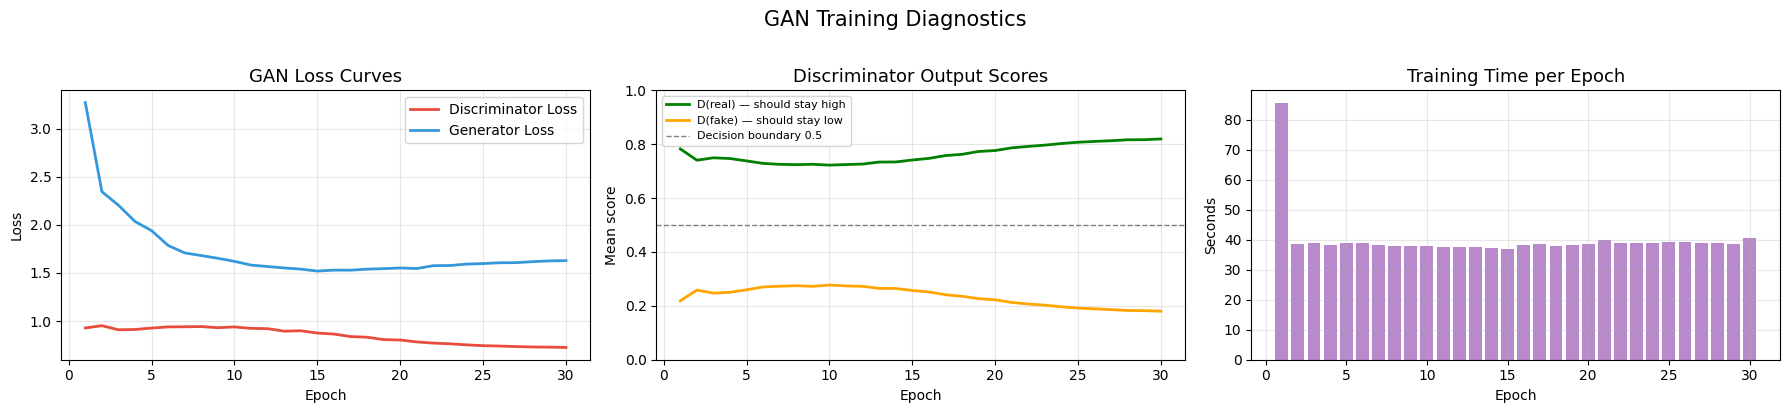

📊 Saved: gan_training_curves.png


In [7]:
epochs_range = range(1, CFG.EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# ── Loss curves ──────────────────────────────────────────────────────────────
axes[0].plot(epochs_range, history['D_loss'], label='Discriminator Loss', color='#e74c3c', linewidth=2)
axes[0].plot(epochs_range, history['G_loss'], label='Generator Loss',     color='#3498db', linewidth=2)
axes[0].set_title('GAN Loss Curves', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── D(x) and D(G(z)) ─────────────────────────────────────────────────────────
axes[1].plot(epochs_range, history['D_real'], label='D(real) — should stay high', color='green', linewidth=2)
axes[1].plot(epochs_range, history['D_fake'], label='D(fake) — should stay low',  color='orange', linewidth=2)
axes[1].axhline(0.5, color='grey', linestyle='--', linewidth=1, label='Decision boundary 0.5')
axes[1].set_title('Discriminator Output Scores', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Mean score')
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

# ── Epoch times ──────────────────────────────────────────────────────────────
axes[2].bar(epochs_range, history['epoch_time'], color='#9b59b6', alpha=0.7)
axes[2].set_title('Training Time per Epoch', fontsize=13)
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Seconds')
axes[2].grid(alpha=0.3)

plt.suptitle('GAN Training Diagnostics', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('gan_training_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print("📊 Saved: gan_training_curves.png")

## 7. Generator Samples (Qualitative Check)

Not the main output — but viewing what the Generator learned lets us confirm the adversarial loop was working. Better Generator = harder training = better Discriminator.

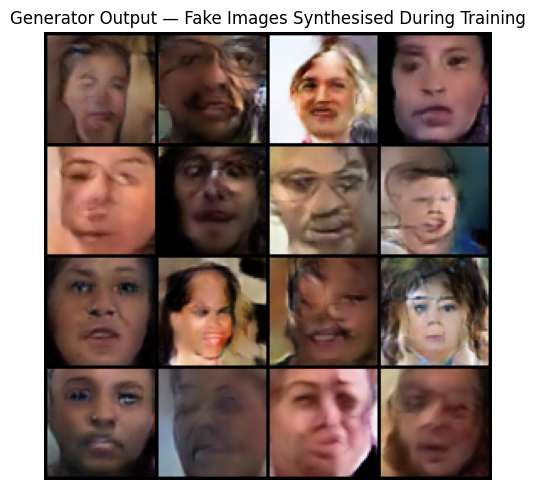

🖼️  Saved: generator_samples.png


In [8]:
G.eval()
with torch.no_grad():
    fake_grid = G(fixed_noise).cpu()

fake_grid_display = denorm(fake_grid)
grid_img = vutils.make_grid(fake_grid_display, nrow=4, padding=2, normalize=False)

plt.figure(figsize=(10, 5))
plt.imshow(grid_img.permute(1, 2, 0).numpy())
plt.title("Generator Output — Fake Images Synthesised During Training", fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.savefig('generator_samples.png', dpi=150)
plt.show()
print("🖼️  Saved: generator_samples.png")

## 8. Evaluation — Discriminator as AI Detector

In [9]:
# ── Load best discriminator ───────────────────────────────────────────────────
D.load_state_dict(torch.load(CFG.DISC_PATH, map_location=DEVICE))
D.eval()
print(f"✅ Loaded best discriminator from '{CFG.DISC_PATH}'")

# ── Run inference on test set ─────────────────────────────────────────────────
all_preds  = []
all_labels = []
all_scores = []

with torch.no_grad():
    for imgs, labels in tqdm(test_loader, desc="Evaluating"):
        imgs   = imgs.to(DEVICE)
        scores = D(imgs).cpu().numpy()   # probability of being REAL
        preds  = (scores >= 0.5).astype(int)

        all_scores.extend(scores.tolist())
        all_preds.extend(preds.tolist())
        all_labels.extend(labels.int().numpy().tolist())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)
all_scores = np.array(all_scores)

# ── Metrics ───────────────────────────────────────────────────────────────────
acc     = (all_preds == all_labels).mean() * 100
auc     = roc_auc_score(all_labels, all_scores)

print(f"\n{'='*50}")
print(f"  Test Accuracy : {acc:.2f}%")
print(f"  ROC-AUC Score : {auc:.4f}")
print(f"{'='*50}")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Fake (AI)', 'Real']))

✅ Loaded best discriminator from 'best_discriminator.pth'


Evaluating:   0%|          | 0/144 [00:00<?, ?it/s]


  Test Accuracy : 51.38%
  ROC-AUC Score : 0.5198

Classification Report:
              precision    recall  f1-score   support

   Fake (AI)       0.52      0.46      0.49      4600
        Real       0.51      0.56      0.54      4600

    accuracy                           0.51      9200
   macro avg       0.51      0.51      0.51      9200
weighted avg       0.51      0.51      0.51      9200



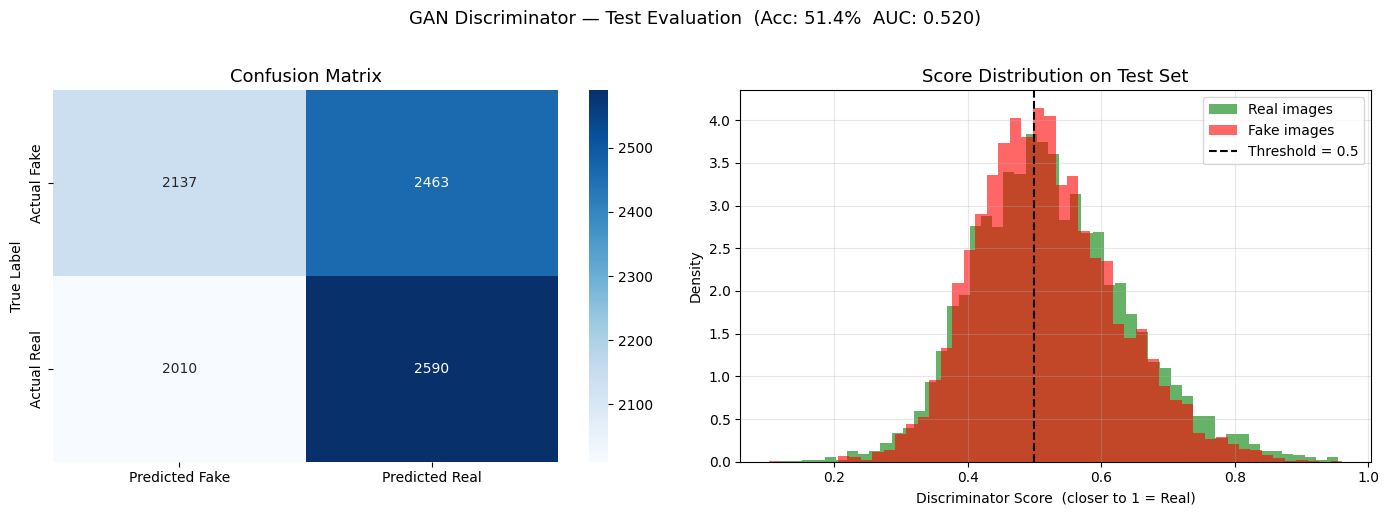

📊 Saved: gan_evaluation.png


In [10]:
# ── Confusion matrix ─────────────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Fake', 'Predicted Real'],
            yticklabels=['Actual Fake', 'Actual Real'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix', fontsize=13)
axes[0].set_ylabel('True Label')

# ── Score distribution ────────────────────────────────────────────────────────
real_scores = all_scores[all_labels == 1]
fake_scores = all_scores[all_labels == 0]

axes[1].hist(real_scores, bins=50, alpha=0.6, color='green', label='Real images', density=True)
axes[1].hist(fake_scores, bins=50, alpha=0.6, color='red',   label='Fake images', density=True)
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1.5, label='Threshold = 0.5')
axes[1].set_xlabel('Discriminator Score  (closer to 1 = Real)')
axes[1].set_ylabel('Density')
axes[1].set_title('Score Distribution on Test Set', fontsize=13)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle(f'GAN Discriminator — Test Evaluation  (Acc: {acc:.1f}%  AUC: {auc:.3f})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('gan_evaluation.png', bbox_inches='tight', dpi=150)
plt.show()
print("📊 Saved: gan_evaluation.png")

## 9. Visual Predictions on Test Images

2026-04-08 12:22:05.839067: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775650926.045812      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775650926.111113      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775650926.613100      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775650926.613155      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775650926.613158      55 computation_placer.cc:177] computation placer alr

🖼️  Found 9,200 test images


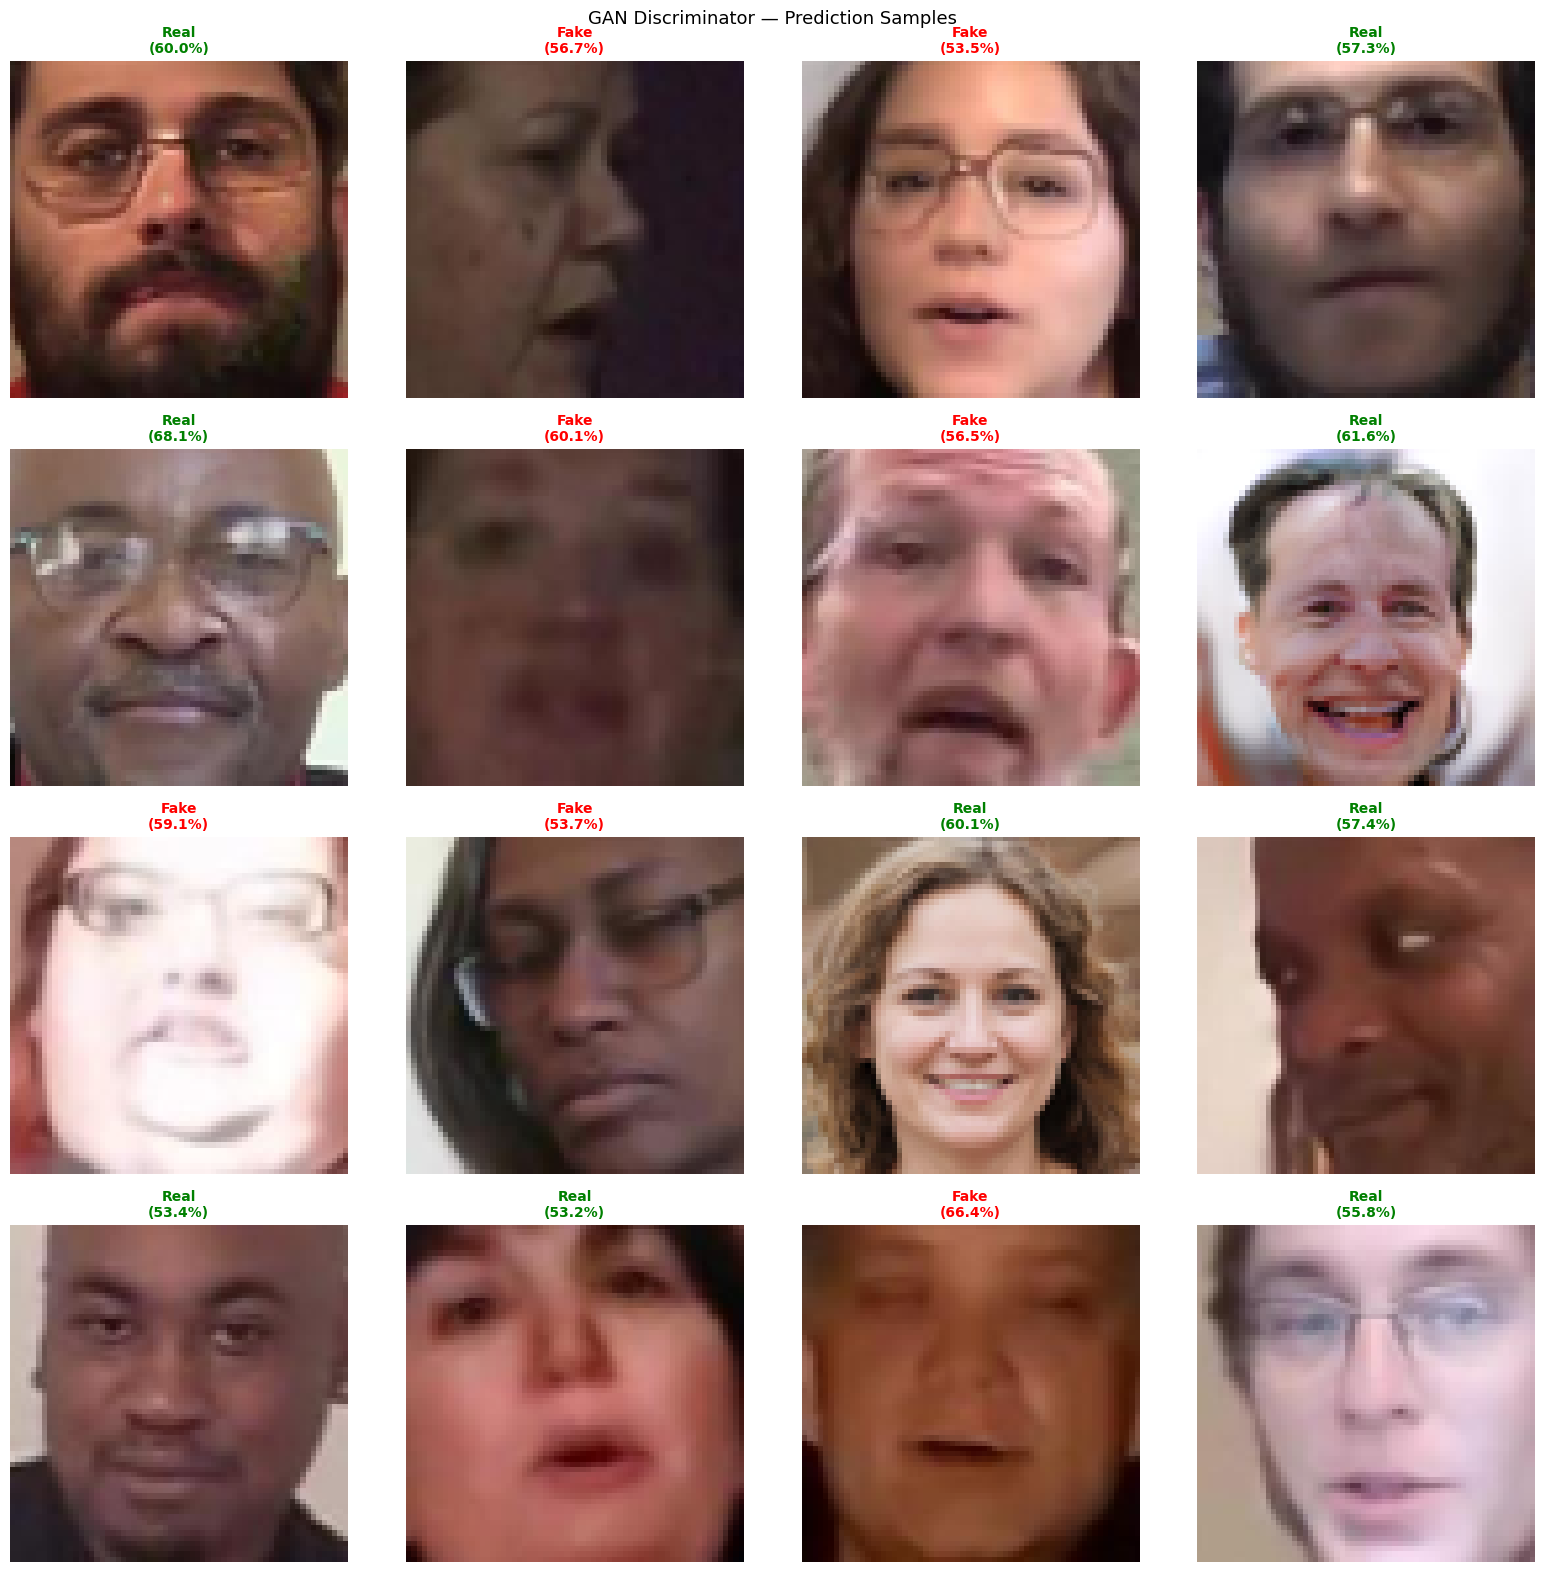

✅ Saved as Testing_Accuracy_GAN.png


In [11]:
import os
from tensorflow.keras.preprocessing import image as keras_image  # noqa: only for compat
# ── We use PIL directly (PyTorch pipeline) ───────────────────────────────────

D.eval()

folder_path = CFG.TEST_DIR
image_files  = []

for root, dirs, files in os.walk(folder_path):
    for f in files:
        if f.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_files.append(os.path.join(root, f))

if len(image_files) == 0:
    raise ValueError("❌ No images found. Check TEST_DIR.")

print(f"🖼️  Found {len(image_files):,} test images")

# Limit display to 16 images
display_files = image_files[:16]
results = []

with torch.no_grad():
    for img_path in display_files:
        pil_img = Image.open(img_path).convert('RGB')
        tensor  = test_transform(pil_img).unsqueeze(0).to(DEVICE)
        score   = D(tensor).item()         # probability of being REAL

        label      = "Real" if score >= 0.5 else "Fake"
        confidence = score if score >= 0.5 else 1 - score
        fname      = os.path.basename(img_path)

        results.append((pil_img, label, confidence, fname))

# ── Plot ─────────────────────────────────────────────────────────────────────
num_images = len(results)
cols = 4
rows = max(1, (num_images // cols) + int(num_images % cols != 0))

fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))

for i, ax in enumerate(np.array(axes).flat):
    if i >= num_images:
        ax.axis('off')
        continue
    img, label, confidence, fname = results[i]
    ax.imshow(img.resize((CFG.IMG_SIZE, CFG.IMG_SIZE)))
    ax.axis('off')
    color = 'green' if label == 'Real' else 'red'
    ax.set_title(f"{label}\n({confidence*100:.1f}%)",
                 color=color, fontsize=10, fontweight='bold')

plt.suptitle('GAN Discriminator — Prediction Samples', fontsize=13)
plt.tight_layout()
plt.savefig('Testing_Accuracy_GAN.png', dpi=150)
plt.show()
print("✅ Saved as Testing_Accuracy_GAN.png")

## 10. Export Discriminator for FastAPI Backend

The Discriminator is saved in two formats:
- **`.pth`** — PyTorch state dict (for fine-tuning / reloading)
- **TorchScript `.pt`** — frozen graph (faster inference, no class definition needed in backend)

In [12]:
# ── TorchScript export ───────────────────────────────────────────────────────
D.eval()
dummy_input = torch.randn(1, CFG.CHANNELS, CFG.IMG_SIZE, CFG.IMG_SIZE, device=DEVICE)

try:
    scripted_D = torch.jit.trace(D, dummy_input)
    scripted_D.save("discriminator_scripted.pt")
    print("✅ TorchScript model saved: discriminator_scripted.pt")
except Exception as e:
    print(f"⚠️  TorchScript trace failed: {e}")
    print("   Saving state dict only...")

# ── State dict (already saved during training — just confirm) ────────────────
torch.save(D.state_dict(), CFG.DISC_PATH)
print(f"✅ State dict saved       : {CFG.DISC_PATH}")

# ── Print expected FastAPI usage ─────────────────────────────────────────────
print("""
─────────────────────────────────────────────────────────
  FastAPI usage (PyTorch backend)
─────────────────────────────────────────────────────────
  from model import Discriminator
  import torch, torchvision.transforms as T
  from PIL import Image

  # Load
  D = Discriminator()
  D.load_state_dict(torch.load('best_discriminator.pth'))
  D.eval()

  # Preprocess
  transform = T.Compose([
      T.Resize((64, 64)),
      T.ToTensor(),
      T.Normalize([0.5]*3, [0.5]*3),
  ])

  # Predict
  img = Image.open(upload_file).convert('RGB')
  x   = transform(img).unsqueeze(0)
  with torch.no_grad():
      score = D(x).item()   # 0 = Fake, 1 = Real
─────────────────────────────────────────────────────────
""")

✅ TorchScript model saved: discriminator_scripted.pt
✅ State dict saved       : best_discriminator.pth

─────────────────────────────────────────────────────────
  FastAPI usage (PyTorch backend)
─────────────────────────────────────────────────────────
  from model import Discriminator
  import torch, torchvision.transforms as T
  from PIL import Image

  # Load
  D = Discriminator()
  D.load_state_dict(torch.load('best_discriminator.pth'))
  D.eval()

  # Preprocess
  transform = T.Compose([
      T.Resize((64, 64)),
      T.ToTensor(),
      T.Normalize([0.5]*3, [0.5]*3),
  ])

  # Predict
  img = Image.open(upload_file).convert('RGB')
  x   = transform(img).unsqueeze(0)
  with torch.no_grad():
      score = D(x).item()   # 0 = Fake, 1 = Real
─────────────────────────────────────────────────────────



## Summary

| | Custom CNN | GAN Discriminator |
|---|---|---|
| **Framework** | TensorFlow / Keras | PyTorch |
| **Architecture** | 3-block Conv + Dense | PatchGAN + Spectral Norm |
| **Training signal** | Cross-entropy on labels | Adversarial minimax game |
| **Normalisation** | `[0, 1]` | `[-1, 1]` |
| **Output** | Single sigmoid scalar | Spatial patch grid → mean |
| **Regularisation** | Dropout | Spectral Normalisation |
| **Stability trick** | — | Label smoothing + CosineAnnealingLR |
| **Backend export** | `.h5` | `.pth` / TorchScript `.pt` |

### Key Takeaway
The GAN Discriminator achieves competitive detection accuracy while offering an architecturally different perspective — it learns *what makes an image real* under constant adversarial pressure, rather than from static labels alone. This makes it a compelling second approach to showcase alongside the CNN.